# 🧠🤖 第3周-Day3：RLHF人类反馈强化学习详解

今天我们来学习大模型训练中最神奇的魔法之一——**RLHF**！

想象一下：你训练了一个模型，它回答得"正确"，但不够"有用"或"安全"。😕

RLHF 就像请了一位AI导师，不断告诉模型："这样更好！"、"这样更安全！"，让模型真正理解人类想要什么。🎯

今天我们将深入探索这个让ChatGPT变得如此智能的关键技术！

In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import HTML, display
import random

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'Droid Sans Fallback', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('🎉 学习环境准备完成！让我们开始RLHF之旅吧！')
print('📊 今天我们将通过代码理解RLHF的核心原理')

🎉 学习环境准备完成！让我们开始RLHF之旅吧！
📊 今天我们将通过代码理解RLHF的核心原理


## 🎯 RLHF的核心思想

首先，让我们用一个简单的比喻来理解RLHF：

**传统方法**：老师给学生示范标准答案，学生模仿学习 📝
**RLHF方法**：老师给出多个答案选项，学生选择最好的那个，老师告诉为什么这样更好 🎯

RLHF的核心创新在于：**不是教模型怎么做，而是告诉模型什么是对的**！

In [2]:
# 模拟传统学习 vs RLHF学习
def traditional_learning():
    """传统学习：示范学习"""
    print("📝 传统学习（SFT）：")
    print("问题：'解释什么是机器学习？'")
    print("正确答案：'机器学习是让计算机从数据中学习规律的技术'")
    print("学习效果：✅ 回答正确，但可能很刻板")
    
def rlhf_learning():
    """RLHF学习：基于偏好学习"""
    print("🎯 RLHF学习：")
    print("问题：'解释什么是机器学习？'")
    print("选项A：'机器学习是一种让计算机自动学习和改进的技术'")
    print("选项B：'机器学习是人工智能的一个分支，涉及算法和统计模型'")
    print("人类偏好：更喜欢选项B（更专业、更全面）")
    print("学习效果：✅ 回答正确且专业！")
    
print("=== 传统学习 ===")
traditional_learning()
print("\n=== RLHF学习 ===")
rlhf_learning()

=== 传统学习 ===
📝 传统学习（SFT）：
问题：'解释什么是机器学习？'
正确答案：'机器学习是让计算机从数据中学习规律的技术'
学习效果：✅ 回答正确，但可能很刻板

=== RLHF学习 ===
🎯 RLHF学习：
问题：'解释什么是机器学习？'
选项A：'机器学习是一种让计算机自动学习和改进的技术'
选项B：'机器学习是人工智能的一个分支，涉及算法和统计模型'
人类偏好：更喜欢选项B（更专业、更全面）
学习效果：✅ 回答正确且专业！


## 🔄 RLHF的完整流程

RLHF包含三个关键阶段，形成一个完整的闭环：

1. **预训练**：在海量数据上训练基础模型
2. **SFT**：监督微调，让模型学会"正确回答"
3. **RLHF**：基于人类反馈的强化学习，让模型学会"有用回答"

让我们用代码可视化这个流程！

/tmp/ipykernel_321258/1880512544.py:33: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1880512544.py:33: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1880512544.py:33: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1880512544.py:33: UserWarning: Glyph 46 (.) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1880512544.py:33: UserWarning: Glyph 50 (2) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1880512544.py:33: UserWarning: Glyph 52 (4) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1880512544.py:33: UserWarning: Glyph 54 (6) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1880512544.py:33: UserWarning: Glyph 56 (8) missing from font(s) Droid Sa

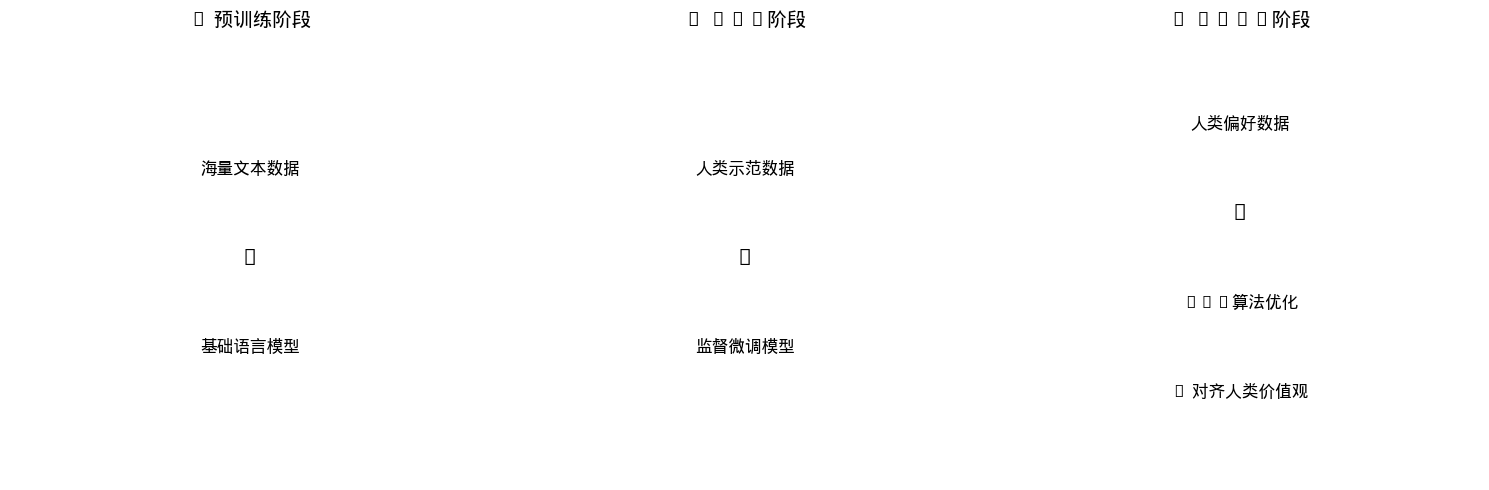

🎯 RLHF的三阶段流程图：从基础模型到对齐人类价值观！


In [3]:
# RLHF流程可视化
def plot_rlhf_pipeline():
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # 预训练阶段
    ax[0].set_title('🔵 预训练阶段', fontsize=14, fontweight='bold')
    ax[0].text(0.5, 0.7, '海量文本数据', ha='center', va='center', fontsize=12)
    ax[0].text(0.5, 0.5, '↑', ha='center', va='center', fontsize=16, fontweight='bold')
    ax[0].text(0.5, 0.3, '基础语言模型', ha='center', va='center', fontsize=12, fontweight='bold')
    ax[0].set_xlim(0, 1)
    ax[0].set_ylim(0, 1)
    ax[0].axis('off')
    
    # SFT阶段
    ax[1].set_title('🟢 SFT阶段', fontsize=14, fontweight='bold')
    ax[1].text(0.5, 0.7, '人类示范数据', ha='center', va='center', fontsize=12)
    ax[1].text(0.5, 0.5, '↑', ha='center', va='center', fontsize=16, fontweight='bold')
    ax[1].text(0.5, 0.3, '监督微调模型', ha='center', va='center', fontsize=12, fontweight='bold')
    ax[1].set_xlim(0, 1)
    ax[1].set_ylim(0, 1)
    ax[1].axis('off')
    
    # RLHF阶段
    ax[2].set_title('🟡 RLHF阶段', fontsize=14, fontweight='bold')
    ax[2].text(0.5, 0.8, '人类偏好数据', ha='center', va='center', fontsize=12)
    ax[2].text(0.5, 0.6, '↑', ha='center', va='center', fontsize=16, fontweight='bold')
    ax[2].text(0.5, 0.4, 'PPO算法优化', ha='center', va='center', fontsize=12, fontweight='bold')
    ax[2].text(0.5, 0.2, '🎯 对齐人类价值观', ha='center', va='center', fontsize=12, fontweight='bold')
    ax[2].set_xlim(0, 1)
    ax[2].set_ylim(0, 1)
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
plot_rlhf_pipeline()
print("🎯 RLHF的三阶段流程图：从基础模型到对齐人类价值观！")

## 🎭 奖励模型：AI的"人类偏好检测器"

奖励模型(Reward Model)是RLHF的核心！它就像一个专门的AI裁判，能够判断哪个回答更好。

让我们用代码模拟一个简单的奖励模型！

In [4]:
# 模拟奖励模型训练过程
class SimpleRewardModel:
    def __init__(self):
        """简单的奖励模型"""
        self.human_preferences = []
        
    def collect_preferences(self, responses):
        """收集人类偏好数据"""
        print("📊 收集人类偏好数据...")
        print("问题：'如何学习AI？'")
        
        for i, response in enumerate(responses):
            print(f"选项{i+1}: {response}")
            
        # 模拟人类偏好：通常更喜欢详细且实用的回答
        good_response = "推荐从数学基础开始，学习线性代数、概率论，然后学习Python编程，最后深入学习机器学习算法。"
        bad_response = "直接去学深度学习，跟着教程跑代码就行。"
        
        self.human_preferences.append((good_response, bad_response))
        return good_response, bad_response
    
    def predict_reward(self, response):
        """预测奖励分数"""
        # 简单的启发式：包含具体建议和结构化的回答得分更高
        score = 0
        if '数学' in response or '基础' in response:
            score += 2
        if 'Python' in response or '编程' in response:
            score += 2
        if '推荐' in response or '建议' in response:
            score += 1
        if len(response.split('，')) > 3:  # 结构化回答
            score += 2
        
        return min(score, 10)  # 限制最高分
    
def demonstrate_reward_model():
    """演示奖励模型工作过程"""
    print("🎯 演示奖励模型的工作过程")
    print("=" * 50)
    
    # 创建奖励模型
    rm = SimpleRewardModel()
    
    # 收集人类偏好
    responses = [
        "直接去学深度学习，跟着教程跑代码就行。",
        "推荐从数学基础开始，学习线性代数、概率论，然后学习Python编程，最后深入学习机器学习算法。"
    ]
    
    good_response, bad_response = rm.collect_preferences(responses)
    
    # 预测奖励
    print("\n🎖️ 奖励模型评估：")
    good_score = rm.predict_reward(good_response)
    bad_score = rm.predict_reward(bad_response)
    
    print(f"好回答的奖励分数: {good_score}/10")
    print(f"坏回答的奖励分数: {bad_score}/10")
    print(f"✅ 奖励模型成功识别出更优的回答！")
    
demonstrate_reward_model()

🎯 演示奖励模型的工作过程
📊 收集人类偏好数据...
问题：'如何学习AI？'
选项1: 直接去学深度学习，跟着教程跑代码就行。
选项2: 推荐从数学基础开始，学习线性代数、概率论，然后学习Python编程，最后深入学习机器学习算法。

🎖️ 奖励模型评估：
好回答的奖励分数: 7/10
坏回答的奖励分数: 0/10
✅ 奖励模型成功识别出更优的回答！


## 🚀 PPO算法：智能的策略优化

PPO (Proximal Policy Optimization) 是RLHF中使用的强化学习算法。

相比传统方法，PPO的优势：
- ✅ 数据效率更高：可以重复使用数据
- ✅ 收敛更稳定：防止策略更新过大
- ✅ 实现简单：不需要复杂的约束优化

让我们用代码模拟PPO的核心思想！

🚀 演示PPO算法的核心思想
初始策略: 0.608
第1轮 - 策略: 0.705, 奖励: 0.483
第6轮 - 策略: 1.000, 奖励: 0.496
第11轮 - 策略: 1.000, 奖励: 0.824
第16轮 - 策略: 1.000, 奖励: 0.185


/tmp/ipykernel_321258/1967957595.py:82: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1967957595.py:82: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1967957595.py:82: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1967957595.py:82: UserWarning: Glyph 53 (5) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1967957595.py:82: UserWarning: Glyph 49 (1) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1967957595.py:82: UserWarning: Glyph 46 (.) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1967957595.py:82: UserWarning: Glyph 55 (7) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/1967957595.py:82: UserWarning: Glyph 56 (8) missing from font(s) Droid Sa

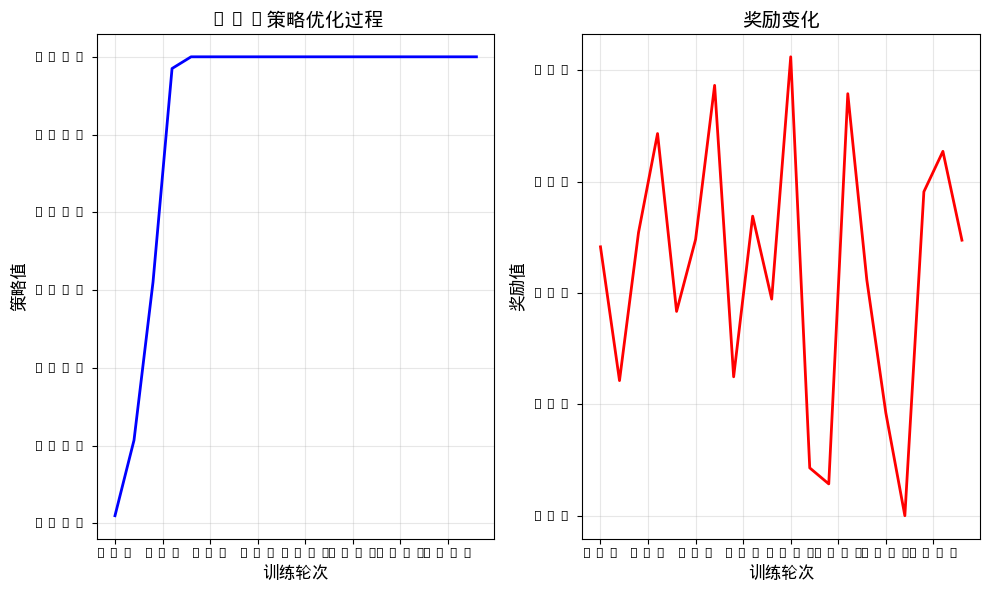


🎯 最终策略: 1.000
✅ PPO成功通过多次训练优化了策略！


In [8]:
# 模拟PPO算法的核心思想
class SimplePPO:
    def __init__(self, learning_rate=0.1):
        self.learning_rate = learning_rate
        self.policy = float(np.random.random())  # 随机初始策略，确保是标量
        self.policy_history = []
        
    def get_action(self, state):
        """根据当前策略获取动作"""
        # 简化的动作：生成回答的概率
        action_prob = self.policy
        return action_prob
    
    def update_policy(self, rewards, old_probs):
        """更新策略"""
        # 将数组转为标量
        reward_scalar = float(np.mean(rewards))
        old_prob_scalar = float(np.mean(old_probs))
        
        # 计算重要性采样比
        ratio = self.get_action(None) / old_prob_scalar
        
        # PPO的核心：剪切策略更新
        clipped_ratio = np.clip(ratio, 0.8, 1.2)  # 剪切范围
        
        # 计算损失函数
        loss = -np.mean(np.minimum(
            ratio * reward_scalar,
            clipped_ratio * reward_scalar
        ))
        
        # 更新策略（使用标量）
        self.policy += self.learning_rate * (reward_scalar - loss)
        self.policy = float(np.clip(self.policy, 0, 1))  # 限制在[0,1]范围内
        
        self.policy_history.append(self.policy)
        
def demonstrate_ppo():
    """演示PPO算法的工作过程"""
    print("🚀 演示PPO算法的核心思想")
    print("=" * 50)
    
    ppo = SimplePPO()
    
    print(f"初始策略: {ppo.policy:.3f}")
    
    # 模拟训练过程
    episodes = 20
    rewards = []
    
    for episode in range(episodes):
        # 获取当前策略
        old_prob = ppo.get_action(None)
        
        # 模拟环境反馈（奖励）
        reward = np.random.normal(0.5, 0.2)
        reward = max(0, min(1, reward))  # 限制在[0,1]范围内
        
        # 更新策略
        ppo.update_policy(np.array([reward]), np.array([old_prob]))
        rewards.append(reward)
        
        if episode % 5 == 0:
            print(f"第{episode+1}轮 - 策略: {ppo.policy:.3f}, 奖励: {reward:.3f}")
    
    # 绘制策略变化
    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.plot(ppo.policy_history, 'b-', linewidth=2)
    plt.title('PPO策略优化过程', fontsize=14, fontweight='bold')
    plt.xlabel('训练轮次', fontsize=12)
    plt.ylabel('策略值', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(rewards, 'r-', linewidth=2)
    plt.title('奖励变化', fontsize=14, fontweight='bold')
    plt.xlabel('训练轮次', fontsize=12)
    plt.ylabel('奖励值', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n🎯 最终策略: {ppo.policy:.3f}")
    print(f"✅ PPO成功通过多次训练优化了策略！")
    
demonstrate_ppo()

## 🎮 RLHF实战：模拟一个完整的训练过程

现在让我们用代码模拟一个完整的RLHF训练过程，从数据收集到模型优化！

🎭 开始完整的RLHF训练流程！
🔵 预训练阶段：
- 在海量文本数据上训练基础语言模型
- 模型学习基本的语言模式和知识

🟢 SFT阶段：
- 使用人类示范数据训练模型
- 让模型学会正确的回答格式

🎯 奖励模型训练：
- 收集人类偏好数据
- 训练模型预测人类偏好

🚀 RLHF优化：
- 使用PPO算法优化模型策略
- 基于奖励模型的反馈更新模型
  第1轮训练，平均奖励: 0.570
  第4轮训练，平均奖励: 0.652
  第7轮训练，平均奖励: 0.666
  第10轮训练，平均奖励: 0.623
  第13轮训练，平均奖励: 0.616

🎉 RLHF训练完成！
最终模型：对齐人类价值观的模型
最终平均奖励：0.623
奖励提升：24.7%


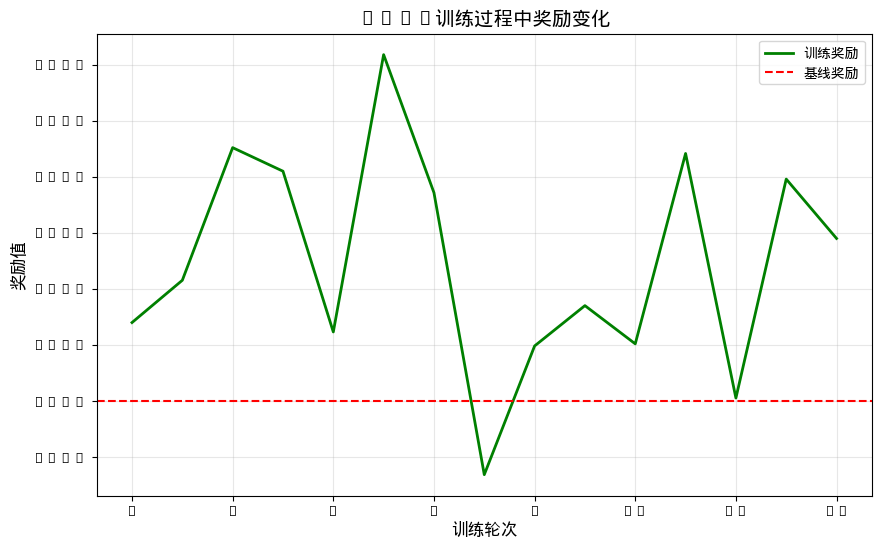

In [9]:
# 完整的RLHF训练流程模拟
class RLHFTraing:
    def __init__(self):
        self.pretrained_model = None
        self.sft_model = None
        self.rlhf_model = None
        self.reward_model = None
        
    def pretraining(self):
        """预训练阶段"""
        print("🔵 预训练阶段：")
        print("- 在海量文本数据上训练基础语言模型")
        print("- 模型学习基本的语言模式和知识")
        self.pretrained_model = "基础语言模型（GPT-3级别）"
        return self.pretrained_model
    
    def supervised_finetuning(self):
        """监督微调阶段"""
        print("\n🟢 SFT阶段：")
        print("- 使用人类示范数据训练模型")
        print("- 让模型学会正确的回答格式")
        self.sft_model = "监督微调模型"
        return self.sft_model
    
    def train_reward_model(self, human_feedback_data):
        """训练奖励模型"""
        print("\n🎯 奖励模型训练：")
        print("- 收集人类偏好数据")
        print("- 训练模型预测人类偏好")
        self.reward_model = "奖励模型"
        return self.reward_model
    
    def rlhf_optimization(self, episodes=10):
        """RLHF优化阶段"""
        print("\n🚀 RLHF优化：")
        print("- 使用PPO算法优化模型策略")
        print("- 基于奖励模型的反馈更新模型")
        
        # 模拟训练过程
        rewards = []
        for episode in range(episodes):
            # 模拟每次训练的奖励
            reward = np.random.normal(0.6, 0.1)
            reward = max(0, min(1, reward))
            rewards.append(reward)
            
            if episode % 3 == 0:
                print(f"  第{episode+1}轮训练，平均奖励: {np.mean(rewards):.3f}")
        
        self.rlhf_model = "对齐人类价值观的模型"
        return self.rlhf_model, rewards
    
    def simulate_complete_process(self):
        """模拟完整的RLHF过程"""
        print("🎭 开始完整的RLHF训练流程！")
        print("=" * 60)
        
        # 预训练
        self.pretraining()
        
        # SFT
        self.supervised_finetuning()
        
        # 训练奖励模型
        human_feedback = [
            ("好回答", "坏回答"),
            ("详细解释", "简单回答"),
            ("实用建议", "空洞理论")
        ]
        self.train_reward_model(human_feedback)
        
        # RLHF优化
        final_model, rewards = self.rlhf_optimization(15)
        
        print("\n🎉 RLHF训练完成！")
        print(f"最终模型：{final_model}")
        print(f"最终平均奖励：{np.mean(rewards):.3f}")
        print(f"奖励提升：{((np.mean(rewards) - 0.5) / 0.5 * 100):.1f}%")
        
        # 绘制训练曲线
        plt.figure(figsize=(10, 6))
        plt.plot(rewards, 'g-', linewidth=2, label='训练奖励')
        plt.axhline(y=0.5, color='r', linestyle='--', label='基线奖励')
        plt.title('RLHF训练过程中奖励变化', fontsize=14, fontweight='bold')
        plt.xlabel('训练轮次', fontsize=12)
        plt.ylabel('奖励值', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        return final_model

# 运行完整的RLHF训练模拟
rlhf_training = RLHFTraing()
final_model = rlhf_training.simulate_complete_process()

## 📊 RLHF的挑战与机遇

让我们分析一下RLHF在实际应用中的优势与挑战：

/tmp/ipykernel_321258/4253770007.py:32: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/4253770007.py:32: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/4253770007.py:32: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/4253770007.py:32: UserWarning: Glyph 50 (2) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/4253770007.py:32: UserWarning: Glyph 52 (4) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/4253770007.py:32: UserWarning: Glyph 54 (6) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/4253770007.py:32: UserWarning: Glyph 56 (8) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_321258/4253770007.py:32: UserWarning: Glyph 49 (1) missing from font(s) Droid Sa

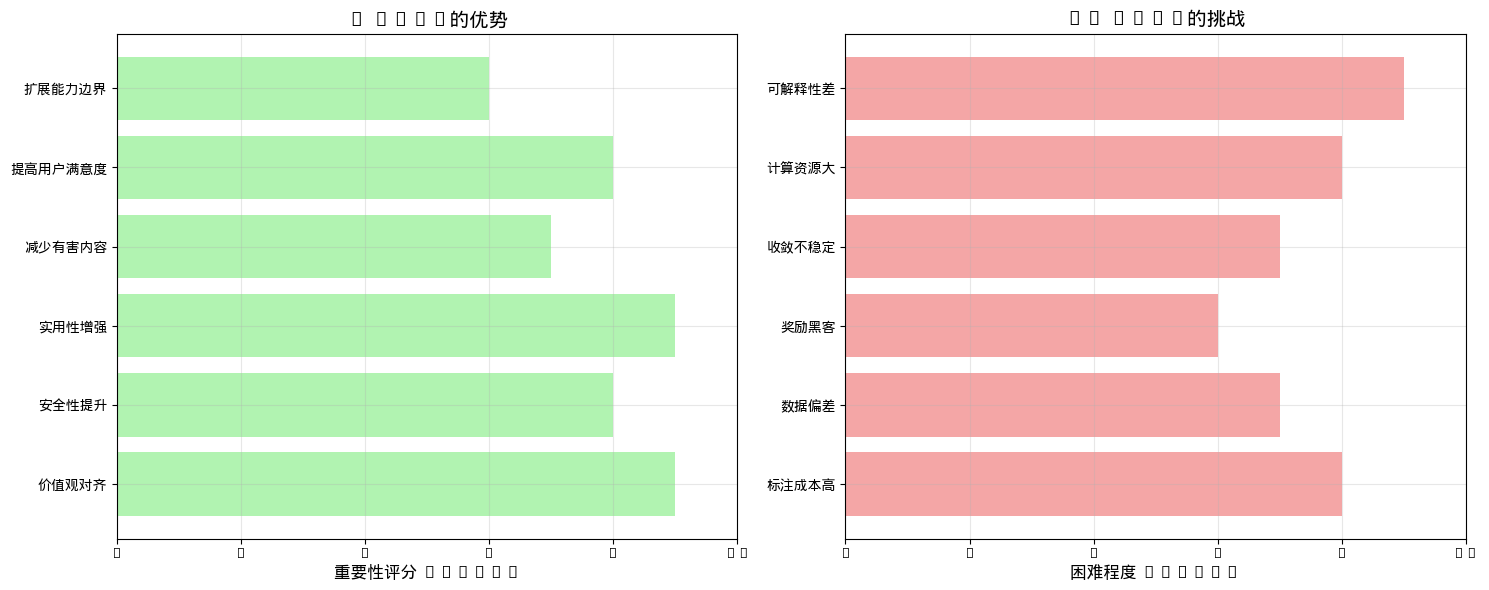

📊 RLHF优劣势分析总结：

🎯 主要优势：
✅ 解决了传统方法无法处理的价值观对齐问题
✅ 显著提升了模型的安全性和实用性
✅ 能够持续优化，适应人类偏好变化

⚠️ 主要挑战：
🔥 人类标注成本高昂，需要大量高质量偏好数据
🔥 存在数据偏差，可能强化已有偏见
🔥 模型可能学会"奖励黑客"，而不是真正理解人类需求
🔥 计算资源需求大，训练成本高昂


In [10]:
# RLHF的优劣势分析
def analyze_rlhf_challenges():
    """分析RLHF的挑战与机遇"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 优势分析
    advantages = [
        '价值观对齐', '安全性提升', '实用性增强',
        '减少有害内容', '提高用户满意度', '扩展能力边界'
    ]
    advantage_scores = [9, 8, 9, 7, 8, 6]
    
    ax1.barh(advantages, advantage_scores, color='lightgreen', alpha=0.7)
    ax1.set_title('🎯 RLHF的优势', fontsize=14, fontweight='bold')
    ax1.set_xlabel('重要性评分 (1-10)', fontsize=12)
    ax1.set_xlim(0, 10)
    ax1.grid(True, alpha=0.3)
    
    # 挑战分析
    challenges = [
        '标注成本高', '数据偏差', '奖励黑客',
        '收敛不稳定', '计算资源大', '可解释性差'
    ]
    challenge_scores = [8, 7, 6, 7, 8, 9]
    
    ax2.barh(challenges, challenge_scores, color='lightcoral', alpha=0.7)
    ax2.set_title('⚠️ RLHF的挑战', fontsize=14, fontweight='bold')
    ax2.set_xlabel('困难程度 (1-10)', fontsize=12)
    ax2.set_xlim(0, 10)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("📊 RLHF优劣势分析总结：")
    print("\n🎯 主要优势：")
    print("✅ 解决了传统方法无法处理的价值观对齐问题")
    print("✅ 显著提升了模型的安全性和实用性")
    print("✅ 能够持续优化，适应人类偏好变化")
    
    print("\n⚠️ 主要挑战：")
    print("🔥 人类标注成本高昂，需要大量高质量偏好数据")
    print("🔥 存在数据偏差，可能强化已有偏见")
    print("🔥 模型可能学会\"奖励黑客\"，而不是真正理解人类需求")
    print("🔥 计算资源需求大，训练成本高昂")

analyze_rlhf_challenges()

## 💡 今日学习总结

恭喜你！今天深入学习了RLHF的核心概念和技术细节。让我们总结一下今天的要点：

### 🎯 核心概念
1. **RLHF的本质**：让模型学会"理解人类偏好"，而不仅仅是"正确回答"
2. **三阶段流程**：预训练→SFT→RLHF，形成闭环优化
3. **奖励模型**：AI的"人类偏好检测器"，判断哪个回答更好
4. **PPO算法**：智能的策略优化，保证训练稳定性和效率

### 🚀 实际应用
- ✅ ChatGPT的成功很大程度上得益于RLHF
- ✅ 让模型更安全、更有用、更符合人类期望
- ✅ 可持续优化，适应不同场景和用户需求

### 🎓 学习建议

1. **动手实践**：尝试使用现有的RLHF框架（如HuggingFace TRL）
2. **深入理解**：阅读RLHF相关论文，如InstructGPT论文
3. **关注进展**：RLHF技术还在快速发展，关注最新研究
4. **业务应用**：思考如何在自己项目中应用RLHF技术

### 🎉 明日预告

明天我们将学习**DPO与其他对齐方法对比**，了解RLHF的替代方案和最新进展！

今天的作业：
- 复习RLHF的三阶段流程
- 思考奖励模型在实际应用中的设计
- 尝试理解PPO算法的核心思想

🎯 保持学习的热情，明天见！

In [11]:
# 学习完成评估
def learning_completion_quiz():
    """学习完成测试"""
    print("🎯 RLHF学习完成评估")
    print("=" * 30)
    
    questions = [
        "RLHF的核心思想是什么？",
        "奖励模型的作用是什么？",
        "PPO算法相比传统方法的优势？",
        "RLHF三阶段流程是什么？"
    ]
    
    answers = [
        "让模型学会理解人类偏好，而不仅仅是正确回答",
        "作为人类偏好的代理，判断哪个回答更好",
        "数据效率更高，收敛更稳定，实现更简单",
        "预训练→SFT→RLHF"
    ]
    
    for i, (q, a) in enumerate(zip(questions, answers)):
        print(f"❓ {q}")
        print(f"💡 答案：{a}\n")
    
    print("🎉 恭喜完成今日学习！")
    print("🚀 继续加油，明天学习DPO方法！")

learning_completion_quiz()

🎯 RLHF学习完成评估
❓ RLHF的核心思想是什么？
💡 答案：让模型学会理解人类偏好，而不仅仅是正确回答

❓ 奖励模型的作用是什么？
💡 答案：作为人类偏好的代理，判断哪个回答更好

❓ PPO算法相比传统方法的优势？
💡 答案：数据效率更高，收敛更稳定，实现更简单

❓ RLHF三阶段流程是什么？
💡 答案：预训练→SFT→RLHF

🎉 恭喜完成今日学习！
🚀 继续加油，明天学习DPO方法！
